# DoubleIntegrator - Stage 4c - Sparse Symbolic vs NN Autograd Safety Gradients

Compare sparse symbolic and neural autograd safety gradients.


In [1]:
import sys, warnings, time, statistics, copy
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
try:
    import pandas as pd
except Exception:
    pd = None

from sdpc.config import load_config
from sdpc.registry import make_system
from sdpc.sindy import load_model
from sdpc.training import build_nn_policy
from sdpc.adaptation import SymbolicSafetyJacobian, SafeAdaptationConfig, run_safe_adaptation
from sdpc.adaptation.analytic import sindy_step
from sdpc.adaptation.rollout import predict_rollout, clamp_action, current_reference, hold_current_reference
from sdpc.adaptation.barrier import rollout_barrier_loss
from sdpc.eval import sample_scenario

SYSTEM = "double_integrator"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"
print(f"System: {SYSTEM}, device={device}")

System: double_integrator, device=cpu


In [2]:
cfg = load_config(CONFIGS / "safe.yaml")
safe_cfg = cfg.get("safe", {})
action_scale = safe_cfg.get("action_scale", cfg.get("action_scale", 1.0))
barrier_kind = safe_cfg.get("barrier_kind", "relaxed_log")
barrier_eps = safe_cfg.get("barrier_eps", 1e-6)
safety_loss_tol = safe_cfg.get("safety_loss_tol", 1e-10)

spec = system.safety_specs(cfg)
sindy = system.perturbed_sindy_model(cfg)
def make_pred_plant(method):
    return lambda x, u: sindy_step(sindy, x, u, system=system, method=method)
pred_plants = {m: make_pred_plant(m) for m in ["euler", "rk4"]}
plant = system.perturbed_plant(cfg)
print("Exact safety dynamics: system.perturbed_sindy_model(cfg)")
print("Safety constraints:", [c.name for c in spec.state_constraints])
print("Control-rate limit:", spec.control_rate is not None)
print("Barrier kind:", barrier_kind)

Exact safety dynamics: system.perturbed_sindy_model(cfg)
Safety constraints: ['obstacle', 'x0_min', 'x0_max', 'x1_min', 'x1_max']
Control-rate limit: True
Barrier kind: relaxed_log


In [ ]:
# Resolve both policies from the uniform checkpoint layout (legacy fallback included).
from sdpc.io import find_nn_checkpoint, find_policy_checkpoint
from sdpc.training import load_nn_policy

sparse_path = find_policy_checkpoint(RESULTS, cfg)
nn_path = find_nn_checkpoint(RESULTS, cfg)
sparse_policy = load_model(sparse_path, device=device).eval()
nn_policy = load_nn_policy(system, nn_path, cfg, device=device)

print("Sparse checkpoint:", sparse_path)
print("NN checkpoint    :", nn_path)
print("Sparse trainable coefficients:", sum(p.numel() for p in sparse_policy.Xi))
print("NN trainable parameters      :", sum(p.numel() for p in nn_policy.parameters()))

In [7]:
symbolic_jacobians = {
    method: SymbolicSafetyJacobian(
        sindy, sparse_policy, system.umin, system.umax,
        system=system, action_scale=action_scale, integration_method=method,
    )
    for method in ["euler", "rk4"]
}

ell = cfg["ellipse"]
x0_eval = torch.tensor([[ell.get("c", 0.0) + 0.25, ell.get("d", 0.0) + 0.25]], dtype=torch.float32, device=device)
r_target = torch.tensor(cfg.get("ref_center", [-3.0, 3.0]), dtype=torch.float32, device=device).view(1, 1, system.nx)
CONSTRAINT_MODES = [("barrier", barrier_kind), ("relu", "relu_hinge")]
INTEGRATORS = ["euler"]
HORIZONS = [5, 10, 20, 40]
WARMUP = 5
N_REP = 20

def make_r_horizon(horizon):
    return r_target.expand(1, horizon, system.nx).contiguous()

def sync():
    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.synchronize()

def zero_module_grads(module):
    for p in module.parameters():
        p.grad = None

def safety_loss_for_kind(x_roll, u_roll, kind):
    loss, _, _ = rollout_barrier_loss(x_roll, spec, kind=kind, eps=barrier_eps, u_traj=u_roll)
    return loss

def summarize_rows(rows):
    if pd is not None:
        return pd.DataFrame(rows)
    for row in rows:
        print(row)

## 1. Sanity Check Losses

Check the expected behavior.


In [8]:
h0, method0 = 20, "euler"
r_h = make_r_horizon(h0)
with torch.no_grad():
    xs, us = predict_rollout(sparse_policy, pred_plants[method0], x0_eval, r_h, h0, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False)
    xn, un = predict_rollout(nn_policy, pred_plants[method0], x0_eval, r_h, h0, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False)
for label, x_roll, u_roll in [("sparse", xs, us), ("nn", xn, un)]:
    vals = {name: float(safety_loss_for_kind(x_roll, u_roll, kind).item()) for name, kind in CONSTRAINT_MODES}
    print(label, vals)

sparse {'barrier': 599289626624.0, 'relu': 620289.0625}
nn {'barrier': 467819036672.0, 'relu': 488818.4375}


## 2. Gradient-Only Benchmark

Measure safety-gradient runtime.


In [9]:
def time_sparse_symbolic_gradient_only(horizon, method, kind, n_rep=N_REP, warmup=WARMUP):
    r_h = make_r_horizon(horizon)
    pred = pred_plants[method]
    sj = symbolic_jacobians[method]
    times, losses, unsafe_count = [], [], 0
    for rep in range(warmup + n_rep):
        with torch.no_grad():
            x_roll, u_roll = predict_rollout(sparse_policy, pred, x0_eval, r_h, horizon, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False)
            loss = safety_loss_for_kind(x_roll, u_roll, kind)
        unsafe = float(loss.detach().cpu().item()) > safety_loss_tol
        sync(); t0 = time.perf_counter()
        if unsafe:
            sj.rollout_sensitivity_grad(x_roll, u_roll, r_h, spec, kind=kind, eps=barrier_eps)
        sync(); elapsed = time.perf_counter() - t0
        if rep >= warmup:
            times.append(elapsed); losses.append(float(loss.detach().cpu().item())); unsafe_count += int(unsafe)
    return {"median_s": statistics.median(times), "loss": statistics.median(losses), "unsafe": unsafe_count}

def time_nn_autograd_gradient_only(horizon, method, kind, n_rep=N_REP, warmup=WARMUP):
    r_h = make_r_horizon(horizon)
    pred = pred_plants[method]
    times, losses, unsafe_count = [], [], 0
    for rep in range(warmup + n_rep):
        zero_module_grads(nn_policy)
        x_roll, u_roll = predict_rollout(nn_policy, pred, x0_eval, r_h, horizon, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=True)
        loss = safety_loss_for_kind(x_roll, u_roll, kind)
        unsafe = float(loss.detach().cpu().item()) > safety_loss_tol
        sync(); t0 = time.perf_counter()
        if unsafe:
            loss.backward()
        sync(); elapsed = time.perf_counter() - t0
        zero_module_grads(nn_policy)
        if rep >= warmup:
            times.append(elapsed); losses.append(float(loss.detach().cpu().item())); unsafe_count += int(unsafe)
    return {"median_s": statistics.median(times), "loss": statistics.median(losses), "unsafe": unsafe_count}

grad_rows = []
for horizon in HORIZONS:
    for cname, kind in CONSTRAINT_MODES:
        for method in INTEGRATORS:
            sy = time_sparse_symbolic_gradient_only(horizon, method, kind)
            ag = time_nn_autograd_gradient_only(horizon, method, kind)
            grad_rows.append({"horizon": horizon, "constraint": cname, "integrator": method,
                              "sparse_symbolic_grad_ms": 1e3 * sy["median_s"],
                              "nn_autograd_backward_ms": 1e3 * ag["median_s"],
                              "speedup_nn_ag_over_sparse_sym": ag["median_s"] / max(sy["median_s"], 1e-12),
                              "sparse_loss": sy["loss"], "nn_loss": ag["loss"],
                              "sparse_unsafe_reps": sy["unsafe"], "nn_unsafe_reps": ag["unsafe"]})
summarize_rows(grad_rows)

,horizon,constraint,integrator,sparse_symbolic_grad_ms,nn_autograd_backward_ms,speedup_nn_ag_over_sparse_sym,sparse_loss,nn_loss,sparse_unsafe_reps,nn_unsafe_reps
0,5,barrier,euler,1.346292,1.137854,0.845177,1.882137e+11,1.805197e+11,20,20
1,5,relu,euler,0.799292,0.667812,0.835505,1.942135e+05,1.865195e+05,20,20
2,10,barrier,euler,1.001417,1.230667,1.228926,3.398167e+11,3.187555e+11,20,20
3,10,relu,euler,0.864521,1.111730,1.285949,3.508164e+05,3.297552e+05,20,20
4,20,barrier,euler,1.177146,2.178604,1.850752,5.992896e+11,4.678190e+11,20,20
5,20,relu,euler,1.099062,2.182083,1.985405,6.202891e+05,4.888184e+05,20,20
6,40,barrier,euler,1.780979,4.264521,2.394481,7.860915e+11,4.678190e+11,20,20
7,40,relu,euler,1.490500,4.273771,2.867340,8.240155e+05,4.888184e+05,20,20


## 3. Rollout + Gradient Benchmark

Measure rollout and gradient runtime.


In [13]:
def time_sparse_symbolic_total(horizon, method, kind, n_rep=N_REP, warmup=WARMUP):
    r_h = make_r_horizon(horizon); pred = pred_plants[method]; sj = symbolic_jacobians[method]
    times, losses, unsafe_count = [], [], 0
    for rep in range(warmup + n_rep):
        sync(); t0 = time.perf_counter()
        with torch.no_grad():
            x_roll, u_roll = predict_rollout(sparse_policy, pred, x0_eval, r_h, horizon, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False)
            loss = safety_loss_for_kind(x_roll, u_roll, kind)
        unsafe = float(loss.detach().cpu().item()) > safety_loss_tol
        if unsafe:
            sj.rollout_sensitivity_grad(x_roll, u_roll, r_h, spec, kind=kind, eps=barrier_eps)
        sync(); elapsed = time.perf_counter() - t0
        if rep >= warmup:
            times.append(elapsed); losses.append(float(loss.detach().cpu().item())); unsafe_count += int(unsafe)
    return {"median_s": statistics.median(times), "loss": statistics.median(losses), "unsafe": unsafe_count}

def time_nn_autograd_total(horizon, method, kind, n_rep=N_REP, warmup=WARMUP):
    r_h = make_r_horizon(horizon); pred = pred_plants[method]
    times, losses, unsafe_count = [], [], 0
    for rep in range(warmup + n_rep):
        zero_module_grads(nn_policy)
        sync(); t0 = time.perf_counter()
        x_roll, u_roll = predict_rollout(nn_policy, pred, x0_eval, r_h, horizon, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=True)
        loss = safety_loss_for_kind(x_roll, u_roll, kind)
        unsafe = float(loss.detach().cpu().item()) > safety_loss_tol
        if unsafe:
            loss.backward()
        sync(); elapsed = time.perf_counter() - t0
        zero_module_grads(nn_policy)
        if rep >= warmup:
            times.append(elapsed); losses.append(float(loss.detach().cpu().item())); unsafe_count += int(unsafe)
    return {"median_s": statistics.median(times), "loss": statistics.median(losses), "unsafe": unsafe_count}

total_rows = []
for horizon in HORIZONS:
    for cname, kind in CONSTRAINT_MODES:
        for method in INTEGRATORS:
            sy = time_sparse_symbolic_total(horizon, method, kind)
            ag = time_nn_autograd_total(horizon, method, kind)
            total_rows.append({"horizon": horizon, "constraint": cname, "integrator": method,
                               "sparse_symbolic_total_ms": 1e3 * sy["median_s"],
                               "nn_autograd_total_ms": 1e3 * ag["median_s"],
                               "speedup_nn_ag_over_sparse_sym": ag["median_s"] / max(sy["median_s"], 1e-12),
                               "sparse_loss": sy["loss"], "nn_loss": ag["loss"],
                               "sparse_unsafe_reps": sy["unsafe"], "nn_unsafe_reps": ag["unsafe"]})
summarize_rows(total_rows)

,horizon,constraint,integrator,sparse_symbolic_total_ms,nn_autograd_total_ms,speedup_nn_ag_over_sparse_sym,sparse_loss,nn_loss,sparse_unsafe_reps,nn_unsafe_reps
0,5,barrier,euler,1.707667,1.688375,0.988703,1.882137e+11,1.805197e+11,20,20
1,5,relu,euler,1.405229,1.244313,0.885487,1.942135e+05,1.865195e+05,20,20
2,10,barrier,euler,2.289813,2.339709,1.021790,3.398167e+11,3.187555e+11,20,20
3,10,relu,euler,2.053271,2.139562,1.042026,3.508164e+05,3.297552e+05,20,20
4,20,barrier,euler,3.524354,4.245188,1.204529,5.992896e+11,4.678190e+11,20,20
5,20,relu,euler,3.259375,3.926959,1.204820,6.202891e+05,4.888184e+05,20,20
6,40,barrier,euler,6.051562,7.852208,1.297551,7.860915e+11,4.678190e+11,20,20
7,40,relu,euler,5.703000,7.481125,1.311788,8.240155e+05,4.888184e+05,20,20


## 4. Online Adaptation Trajectory Visualization

Run online policy adaptation.


sparse symbolic total safety iters: 122
NN autograd total safety iters      : 877
NN visual gains: gamma_ref= 0.01 gamma_safe= 0.001 ref_max_norm= 5.0 safe_max_norm= 2.0
Time execution NN: 4.481357097625732
Time execution Sparse: 1.8959829807281494
       sparse symbolic: final_err=3.0194e-03, xmin=-3.7011, xmax=3.9178, umin=-0.3019, umax=0.4227
           NN autograd: final_err=3.3717e-07, xmin=-3.5505, xmax=3.8177, umin=-0.7372, umax=0.3280


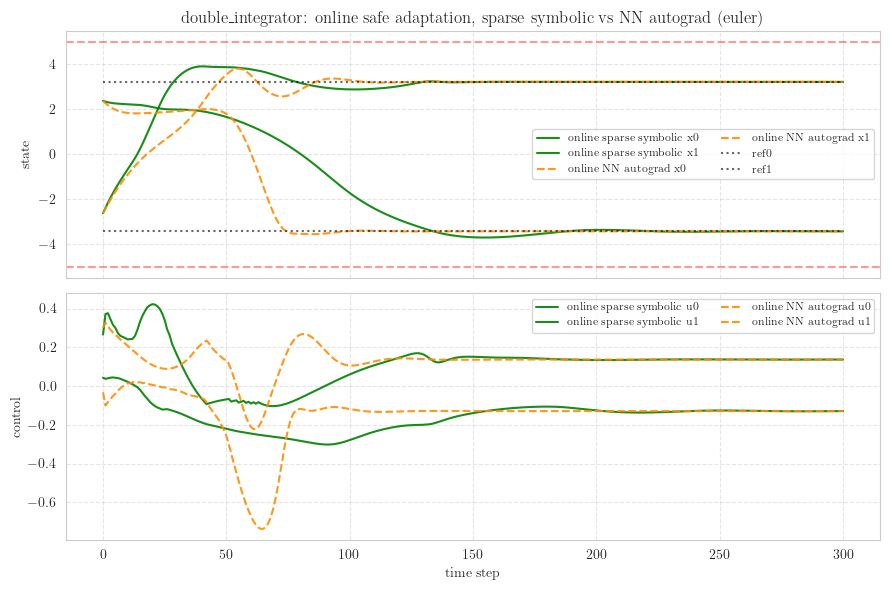

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


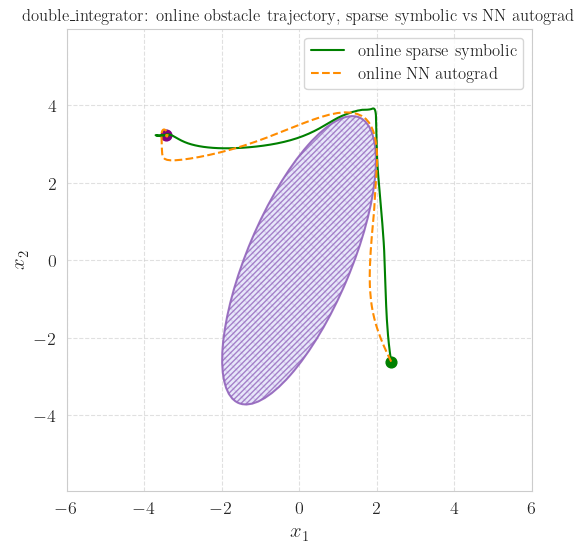

In [72]:
from sdpc.plotting import plot_states_and_controls, plot_trajectories_with_ellipse
import matplotlib.pyplot as plt

visual_method = "euler"
visual_barrier_kind = barrier_kind
visual_cfg = dict(cfg)
visual_cfg["nsteps"] = min(cfg.get("nsteps", 400), 300)
visual_data = sample_scenario(system, visual_cfg, cfg.get("seed", 0), device)
visual_plant = system.perturbed_plant(visual_cfg)
visual_pred_plant = pred_plants[visual_method]

for name, p in nn_policy.named_parameters():
    p.requires_grad_(True)

NN_GAMMA_REF = 1e-2
NN_GAMMA_SAFE = 1e-3
NN_REF_GRAD_MAX_NORM = 5.0
NN_SAFE_GRAD_MAX_NORM = 2.0
NN_CLIP_UPDATE = 0.5


sparse_online_policy = copy.deepcopy(sparse_policy)
sparse_online_cfg = SafeAdaptationConfig(**{**safe_cfg, "barrier_kind": visual_barrier_kind, "integration_method": visual_method, "safety_backend": "symbolic"})

begin_sparse = time.time()
sparse_online = run_safe_adaptation(sparse_online_policy, visual_plant, visual_data, spec, sparse_online_cfg,
                                    umin=system.umin, umax=system.umax, pred_plant=visual_pred_plant,
                                    derivative_model=sindy, system=system)
end_sparse = time.time()

def nn_apply_descent(policy, loss, *, gamma, clip=None, max_norm=None, normalize=False):
    zero_module_grads(policy); loss.backward()
    params = [p for p in policy.parameters() if p.requires_grad]
    grads = [(-p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)) for p in params]
    norm2 = sum((g ** 2).sum() for g in grads)
    raw_norm = torch.sqrt(norm2 + 1e-12); scale = raw_norm.new_tensor(1.0)
    if normalize:
        grads = [g / (1.0 + norm2) for g in grads]
    if max_norm is not None:
        scale = torch.clamp(raw_norm.new_tensor(max_norm) / (raw_norm + 1e-12), max=1.0)
        grads = [scale * g for g in grads]
    with torch.no_grad():
        for p, g in zip(params, grads):
            g = torch.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
            if clip is not None:
                g = g.clamp(min=-clip, max=clip)
            p.add_(gamma * g)
    zero_module_grads(policy)
    return float(raw_norm.detach().cpu().item()), float(scale.detach().cpu().item())

def run_nn_safe_adaptation_autograd(policy, plant, pred_plant, data, cfg_s):
    x_data = data["xn"].detach(); r_data = data["r"].detach()
    B, _, nx = x_data.shape; T, nr = r_data.shape[1], r_data.shape[2]
    x0 = x_data[:, 0, :]
    with torch.no_grad():
        u0 = clamp_action(policy(x0, current_reference(r_data, 0)), system.umin, system.umax, cfg_s.action_scale)
    x_traj = torch.empty(B, T, nx, device=device); u_traj = torch.empty(B, T, u0.shape[-1], device=device)
    x_traj[:, 0, :] = x0; u_traj[:, 0, :] = u0
    logs = []
    for t in range(1, T):
        x = x_traj[:, t - 1, :].detach(); r = current_reference(r_data, t); r_h = hold_current_reference(r_data, t, cfg_s.horizon)
        u_ref = clamp_action(policy(x, r), system.umin, system.umax, cfg_s.action_scale)
        x_ref = pred_plant(x, u_ref)
        ref_loss = 0.5 * ((x_ref - r) ** 2).sum()
        ref_grad_norm, ref_grad_scale = nn_apply_descent(policy, ref_loss, gamma=NN_GAMMA_REF, clip=NN_CLIP_UPDATE,
                                                         max_norm=NN_REF_GRAD_MAX_NORM, normalize=False)
        safe_loss = float("inf"); safe_grad_norm = 0.0; safe_grad_scale = 1.0; m = 0
        while True:
            x_roll, u_roll = predict_rollout(policy, pred_plant, x, r_h, cfg_s.horizon,
                                             umin=system.umin, umax=system.umax,
                                             action_scale=cfg_s.action_scale, grad=True)
            loss = safety_loss_for_kind(x_roll, u_roll, cfg_s.barrier_kind)
            safe_loss = float(loss.detach().cpu().item())
            if safe_loss <= cfg_s.safety_loss_tol or m >= cfg_s.max_safety_iters:
                zero_module_grads(policy); break
            safe_grad_norm, safe_grad_scale = nn_apply_descent(policy, loss, gamma=NN_GAMMA_SAFE * cfg_s.safety_gain,
                                                               clip=NN_CLIP_UPDATE, max_norm=NN_SAFE_GRAD_MAX_NORM,
                                                               normalize=False)
            m += 1
        with torch.no_grad():
            u_apply = clamp_action(policy(x, r), system.umin, system.umax, cfg_s.action_scale)
            x_next = plant(x, u_apply)
        x_traj[:, t, :] = x_next; u_traj[:, t, :] = u_apply
        logs.append({"t": t, "barrier_loss": safe_loss, "safety_iters": m,
                     "ref_grad_norm": ref_grad_norm, "ref_grad_scale": ref_grad_scale,
                     "safe_grad_norm": safe_grad_norm, "safe_grad_scale": safe_grad_scale})
    return {"x_traj": x_traj, "u_traj": u_traj, "logs": logs}

nn_online_policy = copy.deepcopy(nn_policy)
nn_online_cfg = SafeAdaptationConfig(**{**safe_cfg, "barrier_kind": visual_barrier_kind, "integration_method": visual_method, "safety_backend": "autograd", "horizon": 15})
begin_nn = time.time()
nn_online = run_nn_safe_adaptation_autograd(nn_online_policy, visual_plant, visual_pred_plant, visual_data, nn_online_cfg)
end_nn = time.time()
print("sparse symbolic total safety iters:", sum(l["safety_iters"] for l in sparse_online["logs"]))
print("NN autograd total safety iters      :", sum(l["safety_iters"] for l in nn_online["logs"]))
print("NN visual gains: gamma_ref=", NN_GAMMA_REF, "gamma_safe=", NN_GAMMA_SAFE,
      "ref_max_norm=", NN_REF_GRAD_MAX_NORM, "safe_max_norm=", NN_SAFE_GRAD_MAX_NORM)
print("Time execution NN:", end_nn - begin_nn)
print("Time execution Sparse:", end_sparse - begin_sparse)

def summarize_online(name, res):
    x = res["x_traj"].detach(); u = res["u_traj"].detach(); r = visual_data["r"]
    final_err = torch.linalg.norm(x[:, -1, :] - r[:, -1, :], dim=-1).mean().item()
    print(f"{name:>22s}: final_err={final_err:.4e}, xmin={x.min().item():.4f}, xmax={x.max().item():.4f}, umin={u.min().item():.4f}, umax={u.max().item():.4f}")
summarize_online("sparse symbolic", sparse_online)
summarize_online("NN autograd", nn_online)

plot_states_and_controls(
    [
        {"x": sparse_online["x_traj"], "u": sparse_online["u_traj"], "label": "online sparse symbolic", "color": "green"},
        {"x": nn_online["x_traj"], "u": nn_online["u_traj"], "label": "online NN autograd", "color": "darkorange", "linestyle": "--"},
    ],
    r_traj=visual_data["r"], xmin=cfg.get("safe_xmin", system.xmin), xmax=cfg.get("safe_xmax", system.xmax),
    title=f"{SYSTEM}: online safe adaptation, sparse symbolic vs NN autograd ({visual_method})",
)
plt.show()

e = cfg["ellipse"]
plot_trajectories_with_ellipse(
    [
        {"traj": sparse_online["x_traj"], "label": "online sparse symbolic", "color": "green"},
        {"traj": nn_online["x_traj"], "label": "online NN autograd", "color": "darkorange", "linestyle": "--"},
    ],
    r=visual_data["r"], p=e["p"], b=e["b"], c=e["c"], d=e["d"], theta=e.get("theta", 0.0),
    xmin=-6, xmax=6, title=f"{SYSTEM}: online obstacle trajectory, sparse symbolic vs NN autograd",
)
plt.show()

## 5. Notes

Summarize the comparison.
